In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path 
import matplotlib.pyplot as plt

In [2]:
# function to load .fasta sequence:
def load_seq_(path: str, return_meta: bool = False, fasta: bool = True):
    """
    Load a single-entry FASTA/A3M or YAML protein file.

    Parameters
    ----------
    path : str
        Path to the FASTA/A3M or YAML file.
    return_meta : bool, optional
        If True, also return a dict with 'type', 'idx', 'path', and 'header' (for FASTA).

    Returns
    -------
    seq : str
        The sequence from the file.
    mapping_db_seq : dict
        Maps sequence position (as str) to 1-based index.
    meta : dict, optional
        Returned only if return_meta=True and input is FASTA/A3M.
    """
    open_args = {"mode": "r"}
    if not fasta:
        # YAML: open, load, extract sequence
        with open(path, **open_args) as f:
            data = yaml.safe_load(f)
        
        if data is None:
            raise ValueError(f"YAML file {path} is empty or could not be parsed")
        
        if "sequences" not in data:
            available_keys = list(data.keys()) if isinstance(data, dict) else "not a dict"
            raise KeyError(
                f"YAML file {path} does not contain 'sequences' key. "
                f"Available keys: {available_keys}. "
                f"Full data structure: {data}"
            )
        
        if not isinstance(data["sequences"], list) or len(data["sequences"]) == 0:
            raise ValueError(
                f"YAML file {path} has 'sequences' but it is not a non-empty list. "
                f"Value: {data['sequences']}"
            )
        
        if "protein" not in data["sequences"][0]:
            raise KeyError(
                f"YAML file {path} sequence entry does not contain 'protein' key. "
                f"Available keys: {list(data['sequences'][0].keys())}"
            )
        
        if "sequence" not in data["sequences"][0]["protein"]:
            raise KeyError(
                f"YAML file {path} protein entry does not contain 'sequence' key. "
                f"Available keys: {list(data['sequences'][0]['protein'].keys())}"
            )
        
        seq = data["sequences"][0]["protein"]["sequence"]
        mapping_db_seq = {str(i): i + 1 for i in range(len(seq))}
        # For YAML no meta info is available/meaningful for return_meta,
        # so just return two outputs regardless of return_meta
        return seq, mapping_db_seq
    else:
        # FASTA/A3M: open, parse header and sequence lines
        with open(path, **open_args) as f:
            lines = [ln.strip() for ln in f if ln.strip()]
        if not lines or not lines[0].startswith(">"):
            raise ValueError(
                f"File {path} does not look like a FASTA/A3M with a header on the first line."
            )
        header = lines[0]
        seq = "".join(lines[1:])
        mapping_db_seq = {str(i): i + 1 for i in range(len(seq))}
        if return_meta:
            header_body = header[1:]  # remove ">"
            parts = header_body.split("|", maxsplit=2)
            seq_type, idx, msa_path = (parts + [None, None, None])[:3]
            meta = {"type": seq_type, "idx": idx, "path": msa_path, "header": header}
            return seq, mapping_db_seq, meta
        return seq, mapping_db_seq


In [10]:
fasta_dirs = "/Users/thomasbush/Downloads/perturbation_fasta"
original_sequence = Path("/Users/thomasbush/Downloads/original.fasta")
p20_fasta = Path(fasta_dirs) / "p20"
p40_fasta = Path(fasta_dirs) / "p40"
p70_fasta = Path(fasta_dirs) / "p70"

In [11]:
original, _ = load_seq_(original_sequence)

In [28]:
def sim_to_original(ref_seq, seq):
    """Returns list where each element is 1 if character matches, else 0, for each position."""
    # ensure both are strings
    sim = [1 if a == b else 0 for a, b in zip(ref_seq, seq)]
    return sim

def hamming_distance(seq1: str, seq2: str) -> int:
    """Pairwise Hamming distance (same length protein strings)."""
    if len(seq1) != len(seq2):
        raise ValueError(f"length mismatch: {len(seq1)} vs {len(seq2)}")
    return sum(a != b for a, b in zip(seq1, seq2))



In [29]:
# get similarity scores between perturbations (recursive: FASTA may be nested under p20)
seq_20_sim = {}  # idx -> match vector vs original
seq_20_str = {}  # idx -> AA string (for pairwise Hamming)
for fasta_file in sorted(p20_fasta.rglob("*.fasta")):
    seq, _ = load_seq_(fasta_file)
    idx = fasta_file.stem  # e.g. "seq_30010"
    seq_20_str[idx] = seq
    seq_20_sim[idx] = sim_to_original(original, seq)

In [30]:
# Pairwise Hamming distance matrix (n_seqs x n_seqs), order fixed by sorted idx
idx_order = sorted(seq_20_str.keys())
seqs = [seq_20_str[i] for i in idx_order]
n = len(seqs)
hamming_mat = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(i, n):
        d = hamming_distance(seqs[i], seqs[j])
        hamming_mat[i, j] = hamming_mat[j, i] = d

# Optional: wrap as DataFrame with row/col labels
hamming_df = pd.DataFrame(hamming_mat, index=idx_order, columns=idx_order)


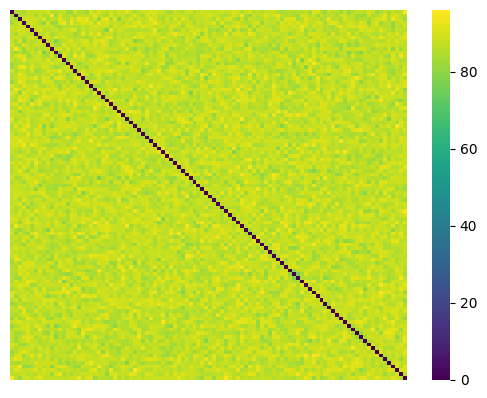

In [32]:
import seaborn as sns
sns.heatmap(hamming_df, cmap="viridis", xticklabels=False, yticklabels=False)
plt.show()

In [33]:
seq_40_sim = {}  # idx -> match vector vs original
seq_40_str = {}  # idx -> AA string (for pairwise Hamming)
for fasta_file in sorted(p40_fasta.rglob("*.fasta")):
    seq, _ = load_seq_(fasta_file)
    idx = fasta_file.stem  # e.g. "seq_30010"
    seq_40_str[idx] = seq
    seq_40_sim[idx] = sim_to_original(original, seq)

In [34]:
# Pairwise Hamming distance matrix (n_seqs x n_seqs), order fixed by sorted idx
idx_order = sorted(seq_40_str.keys())
seqs = [seq_40_str[i] for i in idx_order]
n = len(seqs)
hamming_mat = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(i, n):
        d = hamming_distance(seqs[i], seqs[j])
        hamming_mat[i, j] = hamming_mat[j, i] = d

# Optional: wrap as DataFrame with row/col labels
hamming_df = pd.DataFrame(hamming_mat, index=idx_order, columns=idx_order)


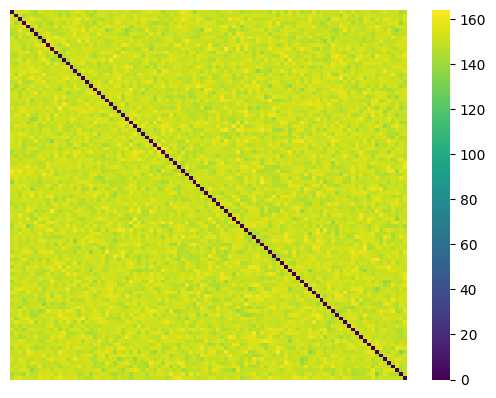

In [35]:

sns.heatmap(hamming_df, cmap="viridis", xticklabels=False, yticklabels=False)
plt.show()

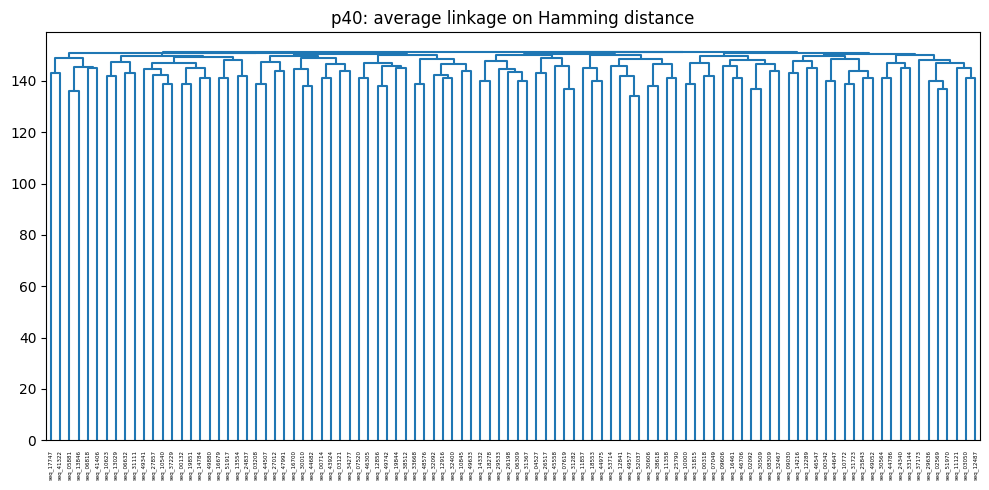

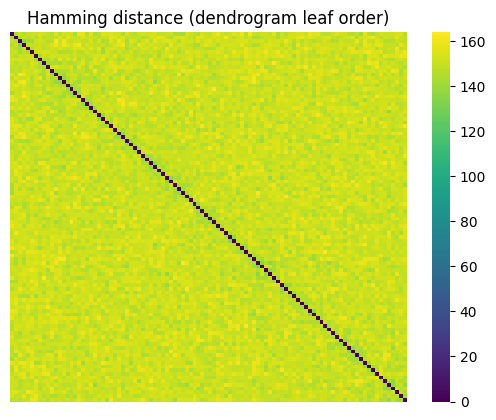

In [36]:
from scipy.cluster.hierarchy import dendrogram, fcluster, leaves_list, linkage
from scipy.spatial.distance import squareform

# Hierarchical clustering on pairwise Hamming (p40)
idx_order_40 = sorted(seq_40_str.keys())
seqs_40 = [seq_40_str[k] for k in idx_order_40]
n40 = len(seqs_40)
hamming_40 = np.zeros((n40, n40), dtype=float)
for i in range(n40):
    for j in range(i, n40):
        d = float(hamming_distance(seqs_40[i], seqs_40[j]))
        hamming_40[i, j] = hamming_40[j, i] = d

Z40 = linkage(squareform(hamming_40, checks=False), method="average")
n_clusters_40 = 8  # tune
labels_40 = fcluster(Z40, t=n_clusters_40, criterion="maxclust")
cluster_df_40 = pd.DataFrame({"idx": idx_order_40, "cluster": labels_40}).sort_values(
    ["cluster", "idx"]
)

fig, ax = plt.subplots(figsize=(max(10, n40 * 0.08), 5))
if n40 <= 100:
    dendrogram(Z40, labels=idx_order_40, ax=ax, leaf_rotation=90.0, leaf_font_size=4)
else:
    dendrogram(Z40, no_labels=True, ax=ax)
ax.set_title("p40: average linkage on Hamming distance")
plt.tight_layout()
plt.show()

order = leaves_list(Z40)
sns.heatmap(
    hamming_40[np.ix_(order, order)],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
)
plt.title("Hamming distance (dendrogram leaf order)")
plt.show()

In [37]:
output_dir = Path('/Users/thomasbush/Downloads/perturbation_outputs/outputs')
score_df = pd.read_csv(output_dir / "p20" / "structure_scores.csv")
score_df.head()

,sequence_idx,predicted_path,tm_score,rmsd
0,132,/n/holylfs06/LABS/bsabatini_lab/Everyone/tbush...,0.921639,1.424726
1,318,/n/holylfs06/LABS/bsabatini_lab/Everyone/tbush...,0.929733,1.353262
2,342,/n/holylfs06/LABS/bsabatini_lab/Everyone/tbush...,0.938373,1.187309
3,714,/n/holylfs06/LABS/bsabatini_lab/Everyone/tbush...,0.932700,1.578956
4,2092,/n/holylfs06/LABS/bsabatini_lab/Everyone/tbush...,0.918217,1.552520


In [ ]:
# Join Hamming clusters to TM-scores via sequence_idx (idx like seq_30010 -> 30010)
score_df_40 = pd.read_csv(output_dir / "p40" / "structure_scores.csv")
cws = cluster_df_40.assign(
    sequence_idx=cluster_df_40["idx"].str.extract(r"seq_(\d+)", expand=False).astype(int)
)
cols_score = [c for c in ["sequence_idx", "tm_score", "rmsd"] if c in score_df_40.columns]
merged_40 = cws.merge(score_df_40[cols_score], on="sequence_idx", how="inner")
miss = (~cws["sequence_idx"].isin(score_df_40["sequence_idx"])).sum()
if miss:
    print(f"{miss} clustered sequences missing from p40 structure_scores")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=merged_40, x="cluster", y="tm_score", ax=axes[0])
axes[0].set_title("TM-score by Hamming cluster (p40)")
sns.stripplot(
    data=merged_40, x="cluster", y="tm_score", alpha=0.35, jitter=True, ax=axes[1]
)
axes[1].set_title("same (strip)")
plt.tight_layout()
plt.show()

display(merged_40.groupby("cluster")["tm_score"].agg(["count", "mean", "std"]))